# *Setup*

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
from numpy import format_float_positional as ffp
from scipy import stats
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

from time import perf_counter
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import clean_data, get_transformers
from src.modeling import random_search_with_kfoldcv, parallelized_random_search_with_kfoldcv
from src.evaluation import (evaluate, evaluate_all_models_and_get_final_comparison_dict,
                            display_best_hyperparam_combinations, display_final_comparison_with_highlight)
from src.utils import save_models, load_models

sns.set_theme(context='notebook', style='ticks')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = clean_data(df)

df_X = df.drop(columns='Churn')
df_y = df.loc[:, ['Churn']].copy()

df_X_train, df_X_test, df_y_train, df_y_test = train_test_split(df_X, df_y, test_size=0.25, shuffle=True, stratify=df_y, random_state=7)
display(df_X_train.shape, df_X_test.shape, df_y_train.shape, df_y_test.shape)

transformers_X, transformer_y = get_transformers(df_X=df_X, df_y=df_y)

models = {}
metrics_final_comparison = {}
model_names_list = ['LR', 'DT', 'RF', 'KNN', 'SVM']

(5282, 19)

(1761, 19)

(5282, 1)

(1761, 1)

# Treinamento e Avaliação Individual dos Modelos

## ***Baseline***: Regressão Logística (**LR**)

In [7]:
X_train_transformed = transformers_X['LR'].fit_transform(df_X_train)
X_test_transformed = transformers_X['LR'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [8]:
models['LR'] = LogisticRegression(C=np.inf,
                                  tol=1e-4,
                                  fit_intercept=True,
                                  solver='lbfgs',
                                  max_iter=1000,
                                  n_jobs=1,
                                  random_state=7)

models['LR'].fit(X=X_train_transformed,
                 y=y_train.reshape(-1))

LogisticRegression(C=inf, max_iter=1000, n_jobs=1, random_state=7)

,Treinamento,Teste
Acurácia,0.808,0.810
Precisão,0.667,0.672
Recall,0.553,0.552
F1-Score,0.605,0.606
F$_{\beta}$-Score,0.572,0.573
AUROC,-----,0.858
AUPRC,-----,0.679


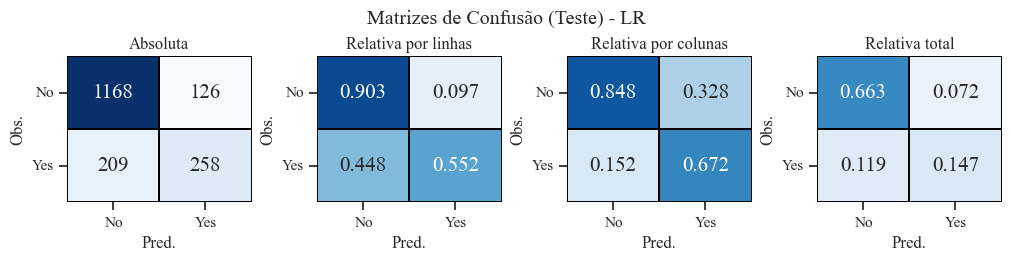

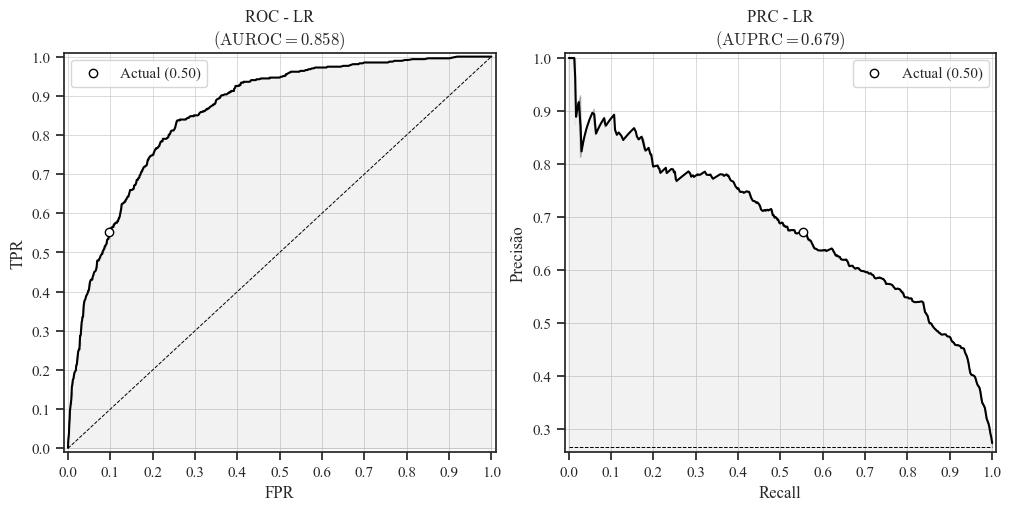

In [9]:
metrics_final_comparison['LR'] = evaluate(
    model=models['LR'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2., threshold=1 / (1 + 1), threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_prc=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_prc=True,
    path_metrics_table='../reports/tables/model-evaluation_LR.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_LR.png',
    path_roc_prc='../reports/figures/roc-pr-curves_LR.png',
    model_title=' - LR')['Teste']

## Árvore de Decisão (**DT**)

### Otimização de Hiperparâmetros

In [4]:
hyperparam_dist = {'ccp_alpha':stats.loguniform(a=1e-4, b=1e3),
                   'criterion':['gini', 'entropy'],
                   'min_samples_split':stats.randint(2, 40+1)}

df_hyperparam_optimization = parallelized_random_search_with_kfoldcv(model=DecisionTreeClassifier(random_state=7),
                                                                     n_comb=1000, k=5,
                                                                     transformer_X=transformers_X['DT'], transformer_y=transformer_y,
                                                                     df_X_train=df_X_train, df_y_train=df_y_train,
                                                                     hyperparam_distributions=hyperparam_dist,
                                                                     n_jobs=5,
                                                                     global_seed=7)
#df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_DT.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     with_one_standard_error_rule=True,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)',
                                     style_format={'ccp_alpha':lambda x: ffp(x)})

,ccp_alpha,criterion,min_samples_split,auc (mean),auc (std),auc (se)
950,0.0025588536991464654,entropy,11,0.825327,0.009445,0.004224
734,0.0025780863732141517,entropy,11,0.825327,0.009445,0.004224
30,0.002716086719845421,entropy,5,0.825207,0.009578,0.004283
453,0.0026797550974218065,entropy,29,0.825207,0.009578,0.004283
655,0.0018799250614313662,entropy,3,0.824398,0.006088,0.002722
778,0.0020716321265925354,entropy,31,0.824378,0.008559,0.003828
219,0.002071140208814707,entropy,32,0.824378,0.008559,0.003828
187,0.0027797196395198728,entropy,18,0.824240,0.008740,0.003908
184,0.0022261659343238895,entropy,36,0.824147,0.010528,0.004708
415,0.002220981905763782,entropy,36,0.824147,0.010528,0.004708


### Treinamento final e Avaliação

In [10]:
X_train_transformed = transformers_X['DT'].fit_transform(df_X_train)
X_test_transformed = transformers_X['DT'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [11]:
# Combinação de hiperparâmetros nº 447
models['DT'] = DecisionTreeClassifier(ccp_alpha=0.0028075893645747984,
                                      min_samples_split=38,
                                      criterion='entropy',
                                      random_state=7)
models['DT'].fit(X=X_train_transformed,
                 y=y_train.reshape(-1))

DecisionTreeClassifier(ccp_alpha=0.0028075893645747984, criterion='entropy',
                       min_samples_split=38, random_state=7)

,Treinamento,Teste
Acurácia,0.791,0.793
Precisão,0.684,0.677
Recall,0.392,0.418
F1-Score,0.499,0.517
F$_{\beta}$-Score,0.429,0.452
AUROC,-----,0.837
AUPRC,-----,0.665


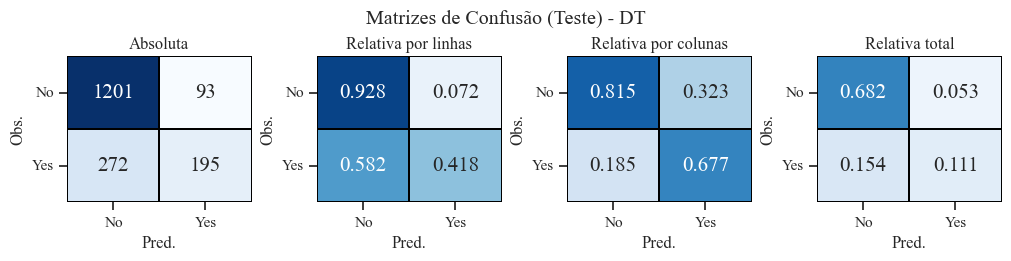

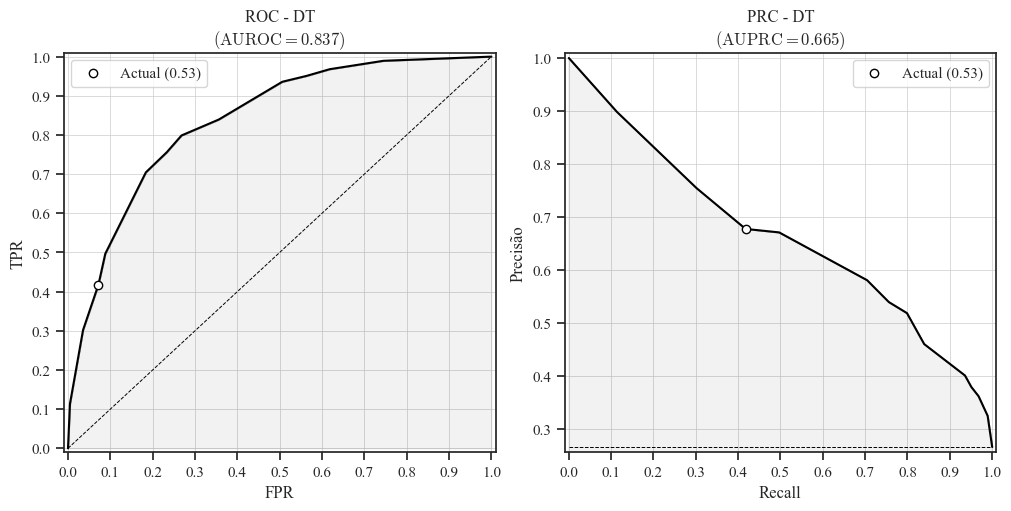

In [12]:
metrics_final_comparison['DT'] = evaluate(
    model=models['DT'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2., threshold=1 / (1 + 1), threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_prc=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_prc=True,
    path_metrics_table='../reports/tables/model-evaluation_DT.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_DT.png',
    path_roc_prc='../reports/figures/roc-pr-curves_DT.png',
    model_title=' - DT')['Teste']

## Floresta Aleatória (**RF**)

### Otimização de Hiperparâmetros

In [15]:
hyperparam_dist = {'n_estimators':stats.randint(10, 500+1),
                   'criterion':['gini', 'entropy'],
                   'max_features':stats.uniform(0, 1),
                   'max_depth':list(range(2, 20+1, 2)) + [None]}

df_hyperparam_optimization = random_search_with_kfoldcv(model=RandomForestClassifier(random_state=7, n_jobs=-1),
                                                        n_comb=100, k=5,
                                                        transformer_X=transformers_X['RF'], transformer_y=transformer_y,
                                                        df_X_train=df_X_train, df_y_train=df_y_train,
                                                        hyperparam_distributions=hyperparam_dist,
                                                        verbose_tqdm=True,
                                                        global_seed=7)
#df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_RF.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     with_one_standard_error_rule=True,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)',
                                     style_format={'max_features':lambda x: ffp(x)})

Validação Cruzada K-Fold - 5/5: 100%|████████████████████████████████████████████████| 100/100 [32:38<00:00, 19.59s/it]


,n_estimators,criterion,max_features,max_depth,auc (mean),auc (std),auc (se)
81,389,gini,0.414901772573252,6,0.841928,0.012438,0.005562
41,458,gini,0.3529783659443947,6,0.841890,0.012517,0.005598
63,262,gini,0.30885268486379713,6,0.841652,0.012437,0.005562
94,487,gini,0.2765630724511342,6,0.841414,0.012530,0.005604
71,401,gini,0.13111064234791392,6,0.840309,0.014485,0.006478
60,359,gini,0.955468323002926,6,0.839985,0.012002,0.005367
25,85,gini,0.13316944575925016,6,0.839800,0.015130,0.006766
22,401,gini,0.2303028790209648,8,0.839634,0.013169,0.005889
67,243,gini,0.9450482237927939,6,0.839627,0.011862,0.005305
43,322,gini,0.3703510829880352,4,0.838682,0.013343,0.005967


### Treinamento final e Avaliação

In [13]:
X_train_transformed = transformers_X['RF'].fit_transform(df_X_train)
X_test_transformed = transformers_X['RF'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [14]:
# Combinação de hiperparâmetros nº 84
models['RF'] = RandomForestClassifier(n_estimators=29,
                                      max_features=0.7963907007825485,
                                      criterion='gini',
                                      max_depth=6,
                                      n_jobs=-1,
                                      random_state=7)
models['RF'].fit(X=X_train_transformed,
                 y=y_train.reshape(-1))

RandomForestClassifier(max_depth=6, max_features=0.7963907007825485,
                       n_estimators=29, n_jobs=-1, random_state=7)

,Treinamento,Teste
Acurácia,0.819,0.809
Precisão,0.711,0.686
Recall,0.536,0.518
F1-Score,0.611,0.590
F$_{\beta}$-Score,0.563,0.545
AUROC,-----,0.854
AUPRC,-----,0.683


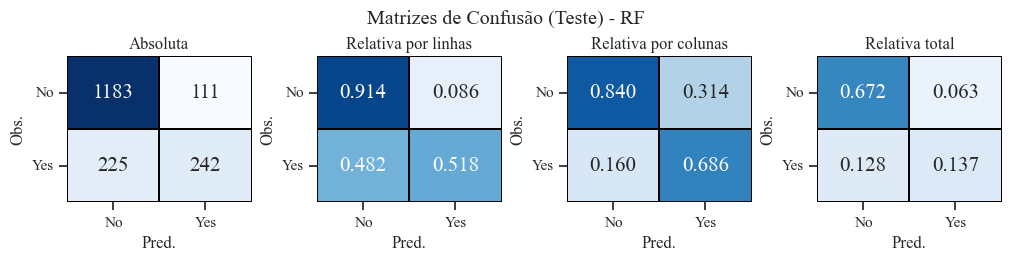

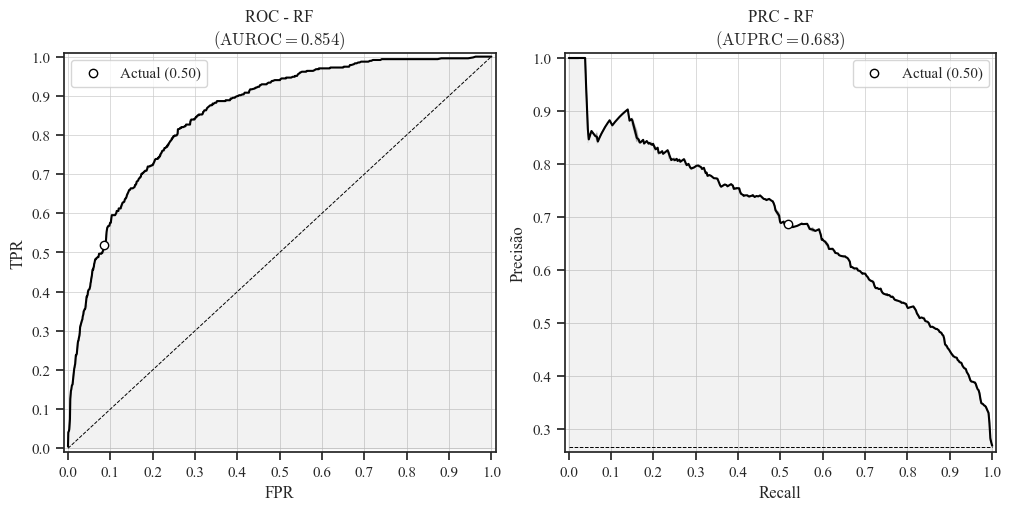

In [15]:
metrics_final_comparison['RF'] = evaluate(
    model=models['RF'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2., threshold=1 / (1 + 1), threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_prc=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_prc=True,
    path_metrics_table='../reports/tables/model-evaluation_RF.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_RF.png',
    path_roc_prc='../reports/figures/roc-pr-curves_RF.png',
    model_title=' - RF')['Teste']

## K-Vizinhos mais Próximos (**KNN**)

### Otimização de Hiperparâmetros

In [10]:
hyperparam_dist = {'n_neighbors':stats.randint(1, 200+1),
                   'weights':['uniform', 'distance'],
                   'p':stats.randint(1, 5+1)}

df_hyperparam_optimization = parallelized_random_search_with_kfoldcv(model=KNeighborsClassifier(metric='minkowski'),
                                                                     n_comb=1000, k=5,
                                                                     transformer_X=transformers_X['KNN'], transformer_y=transformer_y,
                                                                     df_X_train=df_X_train, df_y_train=df_y_train,
                                                                     hyperparam_distributions=hyperparam_dist,
                                                                     n_jobs=5,
                                                                     global_seed=7)
#df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_KNN.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     with_one_standard_error_rule=True,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)')

,n_neighbors,weights,p,auc (mean),auc (std),auc (se)
730,108,uniform,1,0.831602,0.017013,0.007608
159,108,uniform,1,0.831602,0.017013,0.007608
608,107,uniform,1,0.831543,0.017102,0.007648
970,107,uniform,1,0.831543,0.017102,0.007648
146,106,uniform,1,0.831473,0.016928,0.007571
372,104,uniform,1,0.831451,0.017021,0.007612
613,103,uniform,1,0.831414,0.017057,0.007628
410,103,uniform,1,0.831414,0.017057,0.007628
166,110,uniform,1,0.831414,0.017155,0.007672
634,109,uniform,1,0.831366,0.017199,0.007692


### Treinamento final e Avaliação

In [16]:
X_train_transformed = transformers_X['KNN'].fit_transform(df_X_train)
X_test_transformed = transformers_X['KNN'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [17]:
models['KNN'] = KNeighborsClassifier(n_neighbors=22,
                                     weights='uniform',
                                     p=2,
                                     metric='minkowski',
                                     n_jobs=-1)
models['KNN'].fit(X=X_train_transformed,
                  y=y_train.reshape(-1))

KNeighborsClassifier(n_jobs=-1, n_neighbors=22)

,Treinamento,Teste
Acurácia,0.808,0.794
Precisão,0.639,0.612
Recall,0.631,0.612
F1-Score,0.635,0.612
F$_{\beta}$-Score,0.633,0.612
AUROC,-----,0.847
AUPRC,-----,0.658


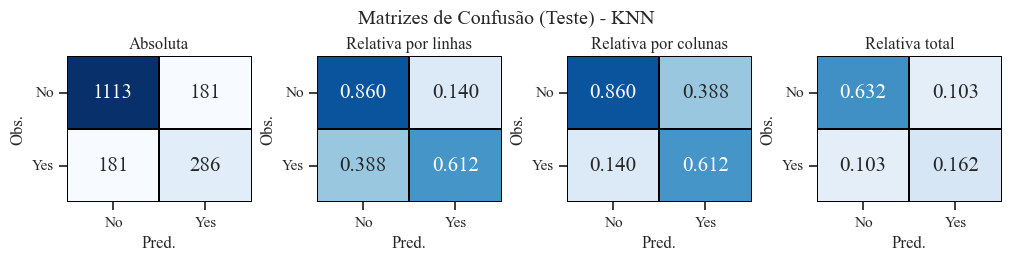

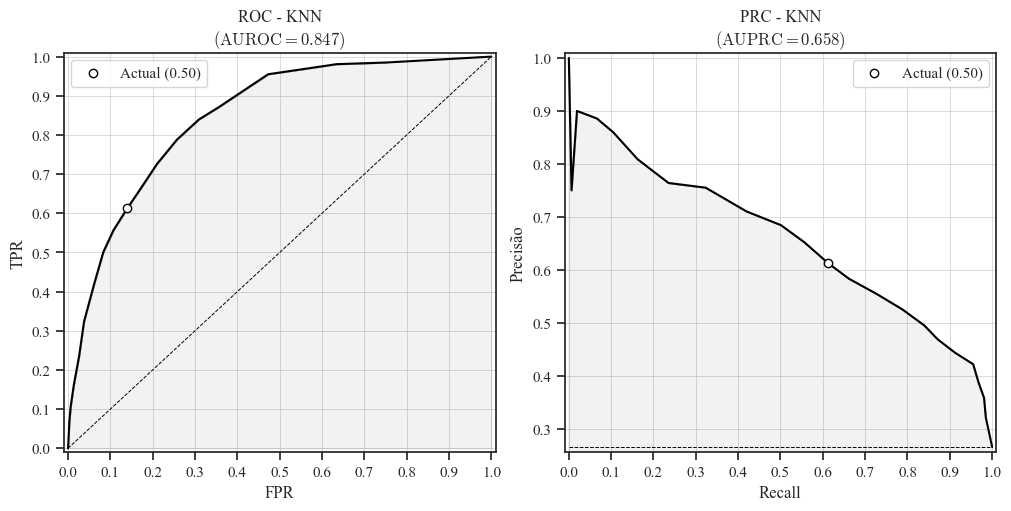

In [18]:
metrics_final_comparison['KNN'] = evaluate(
    model=models['KNN'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2., threshold=1 / (1 + 1), threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_prc=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_prc=True,
    path_metrics_table='../reports/tables/model-evaluation_KNN.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_KNN.png',
    path_roc_prc='../reports/figures/roc-pr-curves_KNN.png',
    model_title=' - KNN')['Teste']

## Máquinas de Vetores de Suporte (**SVM**)

### Otimização de Hiperparâmetros

In [15]:
hyperparam_dist = {'C':stats.loguniform(2**-10, 2**10),
                   'gamma':stats.loguniform(2**-20, 2**5)}

df_hyperparam_optimization = parallelized_random_search_with_kfoldcv(model=SVC(random_state=7, kernel='rbf', probability=True),
                                                                     n_comb=100, k=5,
                                                                     transformer_X=transformers_X['SVM'], transformer_y=transformer_y,
                                                                     df_X_train=df_X_train, df_y_train=df_y_train,
                                                                     hyperparam_distributions=hyperparam_dist,
                                                                     n_jobs=5,
                                                                     global_seed=7)
#df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_SVM.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     n_best=5,
                                     with_one_standard_error_rule=False,
                                     style_format={'C':lambda x:ffp(x), 'gamma':lambda x:ffp(x)})

,C,gamma,auc (mean),auc (std),auc (se)
92,0.0017158226880264926,0.00000192914796952792,0.831361,0.019382,0.008668
56,0.003508930082791008,0.000004717842365609852,0.831327,0.019397,0.008674
19,0.001379139923285146,0.0000014682007641057004,0.831320,0.019505,0.008723
16,0.018810826796744964,0.00003848441491494224,0.831281,0.019720,0.008819
55,0.0009960719731237507,0.0000009775487685593361,0.831235,0.019476,0.008710


### Treinamento final e Avaliação

In [19]:
X_train_transformed = transformers_X['SVM'].fit_transform(df_X_train)
X_test_transformed = transformers_X['SVM'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [20]:
models['SVM'] = SVC(C=0.0017158226880264926,
                    gamma=0.00000192914796952792,
                    kernel='rbf',
                    probability=True,
                    random_state=7)
models['SVM'].fit(X=X_train_transformed,
                  y=y_train.reshape(-1))

SVC(C=0.0017158226880264926, gamma=1.92914796952792e-06, probability=True,
    random_state=7)

,Treinamento,Teste
Acurácia,0.795,0.800
Precisão,0.626,0.637
Recall,0.561,0.567
F1-Score,0.592,0.600
F$_{\beta}$-Score,0.573,0.580
AUROC,-----,0.847
AUPRC,-----,0.665


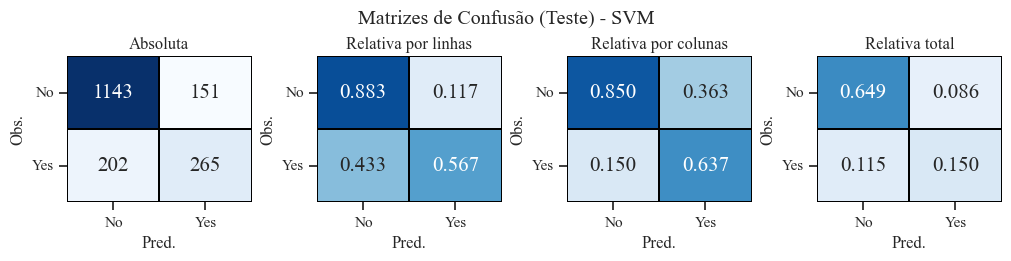

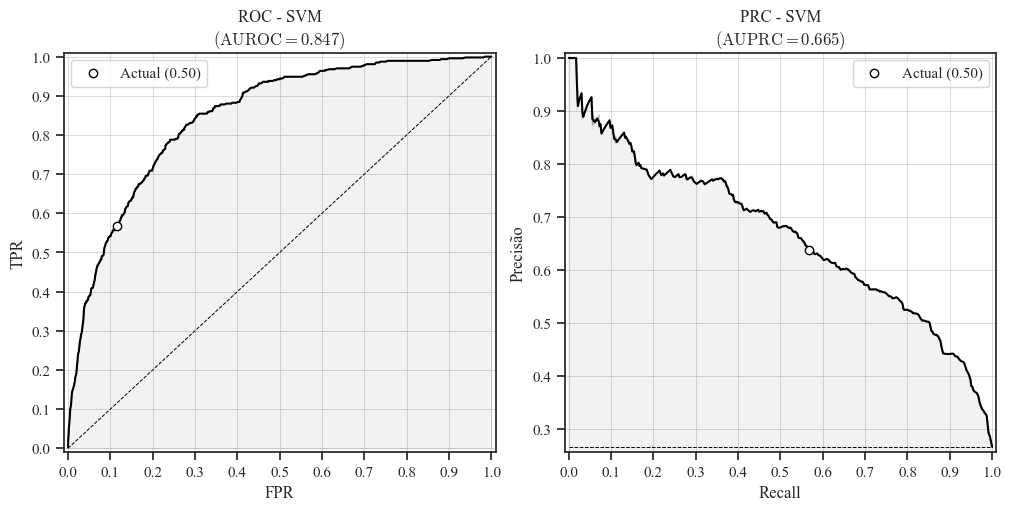

In [21]:
metrics_final_comparison['SVM'] = evaluate(
    model=models['SVM'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2., threshold=1 / (1 + 1), threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_prc=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_prc=True,
    path_metrics_table='../reports/tables/model-evaluation_SVM.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_SVM.png',
    path_roc_prc='../reports/figures/roc-pr-curves_SVM.png',
    model_title=' - SVM')['Teste']

# Salvando e Carregando os Modelos Treinados

In [44]:
save_models(models, path='../models/', format='.pkl')

In [3]:
models = load_models(['LR', 'DT', 'KNN', 'RF', 'SVM'], path='../models/', format='.pkl')

# Comparação Final entre Modelos

#### **Observações da comparação final:**
- Qualquer modelo obteve performance consideralmente melhor do que os modelos aleatórios (**RG** e **IRG**);
- A Regressão Logística (**LR**) e a Árvore de Decisão (**DT**), por mais que não tenham sido campeãs estritas em nenhuma métrica, oferecem valores bem competitivos de precisão (ambas) e *AUC* (**LR**) com relação aos melhores modelos, sem contar o fato de serem os modelos mais interpretáveis e computacionalmente leves;
- O modelo de Floresta Aleatória (**RF**) foi o **campeão em Precisão e *AUC***. Apesar disso, o seu *Recall* deixa a desejar, e em termos de visão de negócio, essa métrica é mais importante neste projeto;
- O modelo de Máquinas de Vetores de Suporte (**SVM**) foi o **campeão em *Recall***. Apesar disso, a sua Precisão deixa a desejar, mas como o *Recall* tende a ser a métrica mais importante neste projeto, o seu $\text{F}_{\beta}\text{ -Score}$ com peso $\beta=2$ para o *Recall* também foi o melhor;
- O modelo de Análise Discriminante *Naive Bayes* (**NB**), apesar de não ter sido campeão estrito, teve métricas quase iguais ao **SVM**, com um *Recall* levemente menor, ao passo que a Precisão foi um pouco maior, $\text{F}_{1}\text{ -Score}$ campeão e $\text{F}_{\beta}\text{ -Score}$ praticamente igual, o que o torna também como uma segunda opção mais leve e com construção probabilística, se considerarmos que o *Recall* tornou o *SVM* o campeão geral;
- O modelo de K-Vizinhos mais Próximos (**KNN**) não se mostrou com nenhuma vantagem competitiva; também não esteve entre os que mais deixaram a desejar, sendo um intermediário em todas as métricas.

#### **Conclusão:** O modelo **SVM**, ou até mesmo o **NB**, devem ser escolhidos.

In [4]:
metrics_final_comparison = evaluate_all_models_and_get_final_comparison_dict(models=models,
                                                                             transformers_X=transformers_X, transformer_y=transformer_y,
                                                                             df_X_train=df_X_train, df_X_test=df_X_test,
                                                                             df_y_train=df_y_train, df_y_test=df_y_test,
                                                                             threshold=0.5, beta_fscore=2.)

In [5]:
display_final_comparison_with_highlight(metrics_final_comparison_dict=metrics_final_comparison,
                                        table_title='Métricas no Conjunto de Testes - Comparação Final - Limiar 0.5',
                                        save_table=True, path_table='../reports/tables/final-comparison_standard-threshold.csv')

,LR,DT,KNN,RF,SVM
Acurácia,0.810,0.793,0.794,0.809,0.800
Precisão,0.672,0.677,0.612,0.686,0.637
Recall,0.552,0.418,0.612,0.518,0.567
F1-Score,0.606,0.517,0.612,0.590,0.600
F$_{\beta}$-Score,0.573,0.452,0.612,0.545,0.580
AUROC,0.858,0.837,0.847,0.854,0.847
AUPRC,0.679,0.665,0.658,0.683,0.665
